In [2]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
#import glob

#import matplotlib.patches as mpatches
#import matplotlib.path as mpath 
#from matplotlib.collections import PathCollection
import matplotlib.colors as mcolors


#import cv2
#from PIL import Image, ImageSequence
#import av
#from matplotlib.colors import Normalize
#from matplotlib.cm import ScalarMappable
#import matplotlib.gridspec as gridspec


In [3]:
# Function to sort files naturally
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

# Function to calculate SSIM
def calculate_ssim(original_file, compressed_file):
    ssim_scores = []
    with tifffile.TiffFile(original_file) as tif_original:
        with tifffile.TiffFile(compressed_file) as tif_compressed:
            for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                original_image = original_frame.asarray()
                compressed_image = compressed_frame.asarray()
                score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                ssim_scores.append(score)
    return np.median(ssim_scores) 

# New function to calculate SSIM
def calculate_ssim_folder(original_folder, compressed_folder):
    ssim_results = []
    original_files = natsorted([f for f in os.listdir(original_folder) if f.endswith('.tiff') and not f.startswith('.')])
    compressed_files = natsorted([f for f in os.listdir(compressed_folder) if f.endswith('.tiff') and not f.startswith('.')])
    
    for original_file, compressed_file in zip(original_files, compressed_files):
        ssim_scores = []
        try:
            with tifffile.TiffFile(os.path.join(original_folder, original_file)) as tif_original:
                with tifffile.TiffFile(os.path.join(compressed_folder, compressed_file)) as tif_compressed:
                    for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                        original_image = original_frame.asarray()
                        compressed_image = compressed_frame.asarray()
                        score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                        ssim_scores.append(score)
            if ssim_scores:
                median_ssim = np.median(ssim_scores)
                ssim_results.append({'original_file': original_file, 'compressed_file': compressed_file, 'ssim': median_ssim})
        except Exception as e:
            print(f"Error processing files {original_file} and {compressed_file}: {e}")
    return ssim_results


# Function to get the total size of files in a folder
def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    for file in os.listdir(folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(folder_path, file))
    return total_size

# Function to extract the k and lev values from the label
def extract_k_lev(label):
    """
    Extracts the k and lev values from the label.
    Assumes the label format is like 'sparz_k5_rt35_lev0'.
    """
    k_match = re.search(r'_k(\d+)_', label)
    lev_match = re.search(r'_lev(\d+)', label)
    k_value = int(k_match.group(1)) if k_match else None
    lev_value = int(lev_match.group(1)) if lev_match else None
    return k_value, lev_value

# Astigmatism data

In [3]:

# Change these paths according to your directory structure
main_folder = '/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism'
original_file = '/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism_raw/sequence-as-stack-MT0.N1.HD-AS-Exp.tif'

In [5]:

# Original file size
original_file_size = 20822904   # in bytes


# Color map for kernel sizes
k_colors = plt.cm.viridis(np.linspace(0, 1, 4))
lev_shades = np.linspace(0.5, 1, 4)
k_values = [5,7,9,11]

# Marker map for threshold values
threshold_markers = {35: 'o', 45: '^', 55: 's', 65: 'd'}

# Iterate through each subfolder and calculate median SSIM score and file size
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
        # Handling different file endings by searching for the common beginning
        for file_name in os.listdir(uncompressed_folder):
            if file_name.startswith('MT0_sequence-as-stack-MT0.N1'):
                compressed_file = os.path.join(uncompressed_folder, file_name)
                break
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])  
        file_size_percentage = (total_file_size / original_file_size) * 100
        k_value, lev_value = extract_k_lev(folder)
        threshold = int(re.search(r'rt(\d+)', folder).group(1))  # Extract threshold value

        # Choose marker based on threshold value
        marker = threshold_markers[threshold]

        color = k_colors[k_values.index(k_value)]

        # Choose shade based on lev value
        shade = lev_shades[lev_value] if lev_value is not None else 0.5

        if lev_value not in results:
            results[lev_value] = []
        results[lev_value].append({'median_ssim': median_ssim, 'file_size_percentage': file_size_percentage, 'color': color, 'shade': shade, 'marker': marker })



In [6]:
# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (level, data_list) in enumerate(sorted(results.items())):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for data in data_list:
        ax.scatter(data['file_size_percentage'], data['median_ssim'], color=data['color'],s=250, marker=data['marker'], alpha=0.9)
    ax.set_xlim(0, 50)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

plt.tight_layout()
#plt.show()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_SSIM_filesize_240731.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()

### Make astigmatism cartoon

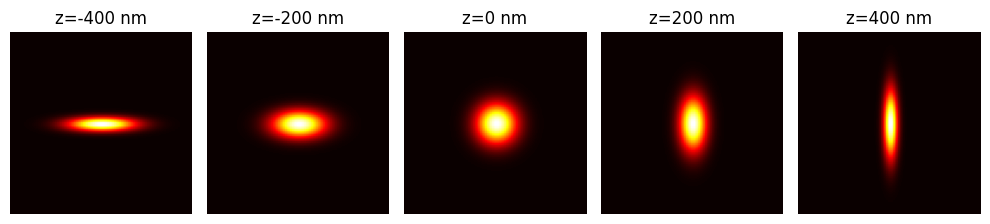

In [7]:
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib.colors import LogNorm

def elliptical_gaussian(x, y, sigma_x, sigma_y):
    """
    Generate a 2D elliptical Gaussian function.
    
    Parameters:
    - x: x coordinates
    - y: y coordinates
    - sigma_x: standard deviation in x direction
    - sigma_y: standard deviation in y direction
    
    Returns:
    - 2D elliptical Gaussian function values.
    """
    return np.exp(-((x / sigma_x)**2 + (y / sigma_y)**2) / 2)

def generate_astigmatic_psf(image_size, dxy, dz, sigma_0x, sigma_0y, Ax, Ay, Bx, By, z_positions):
    """
    Generate a series of 2D Gaussian point spread functions (PSF) with astigmatism at different z-positions.
    
    Parameters:
    - image_size: tuple of (height, width) of the output image.
    - dxy: pixel size in xy-plane in microns.
    - dz: pixel size in z-direction in microns.
    - sigma_0x: base standard deviation in x direction.
    - sigma_0y: base standard deviation in y direction.
    - Ax, Ay: astigmatism coefficients.
    - Bx, By: higher-order astigmatism coefficients.
    - z_positions: list of z positions for which to generate the PSFs.
    
    Returns:
    - psfs: list of 2D arrays representing the PSFs at different z-positions.
    """
    y = np.linspace(-image_size[0]//2, image_size[0]//2, image_size[0]) * dxy
    x = np.linspace(-image_size[1]//2, image_size[1]//2, image_size[1]) * dxy
    x, y = np.meshgrid(x, y, indexing='ij')
    
    psfs = []
    for z in z_positions:
        sigma_x = sigma_0x + Ax * z + Bx * z**2
        sigma_y = sigma_0y + Ay * z + By * z**2
        psf = elliptical_gaussian(x, y, sigma_x, sigma_y)
        psfs.append(psf)
    
    return psfs

# Parameters
image_size_2d = (77, 77)
dxy = 0.05
dz = 0.05

# Adjustable parameters
sigma_0x = 0.3
sigma_0y = 0.3
Ax = 0.5
Ay = -0.5
Bx = 0.01
By = 0.01
z_positions = [-0.4, -0.2, 0, 0.2, 0.4]  # Z positions in microns

# Visualization parameters
vmin = 1e-6  # Minimum value for normalization
vmax = 1.0   # Maximum value for normalization
colormap = 'hot'  # Colormap to use, e.g., 'hot', 'viridis', 'plasma', etc.

# Generate elliptical PSFs with astigmatism at different z-positions
psfs_astigmatic = generate_astigmatic_psf(image_size_2d, dxy, dz, sigma_0x, sigma_0y, Ax, Ay, Bx, By, z_positions)

# Plot the results
fig, axs = plt.subplots(1, 5, figsize=(10, 5))

for i, (psf, z) in enumerate(zip(psfs_astigmatic, z_positions)):
    # Manually set background to zero
    axs[i].imshow(psf, cmap=colormap, extent=[-image_size_2d[1]//2, image_size_2d[1]//2, -image_size_2d[0]//2, image_size_2d[0]//2])
    axs[i].set_title(f'z={z * 1000:.0f} nm')
    axs[i].set_xlabel('X')
    axs[i].set_ylabel('Y')
    axs[i].axis('off')

plt.tight_layout()
# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_astigmatic_psf.pdf'
plt.savefig(output_file, format='pdf')
plt.show()


### Overview images for grid search


In [8]:
# Define the parameters used in grid search
kernel_sizes = list(range(5, 12, 2))  # 5, 7, 9, 11
rel_thresholds = [0.35, 0.45, 0.55, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


In [9]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array


# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds), figsize=(12, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['sequence-as-stack-MT0.N1.HD-AS-Exp.npz'] 
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) + index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('#eeeeee')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')


                            # Set title 
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.02) 

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure4_astigmatism.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

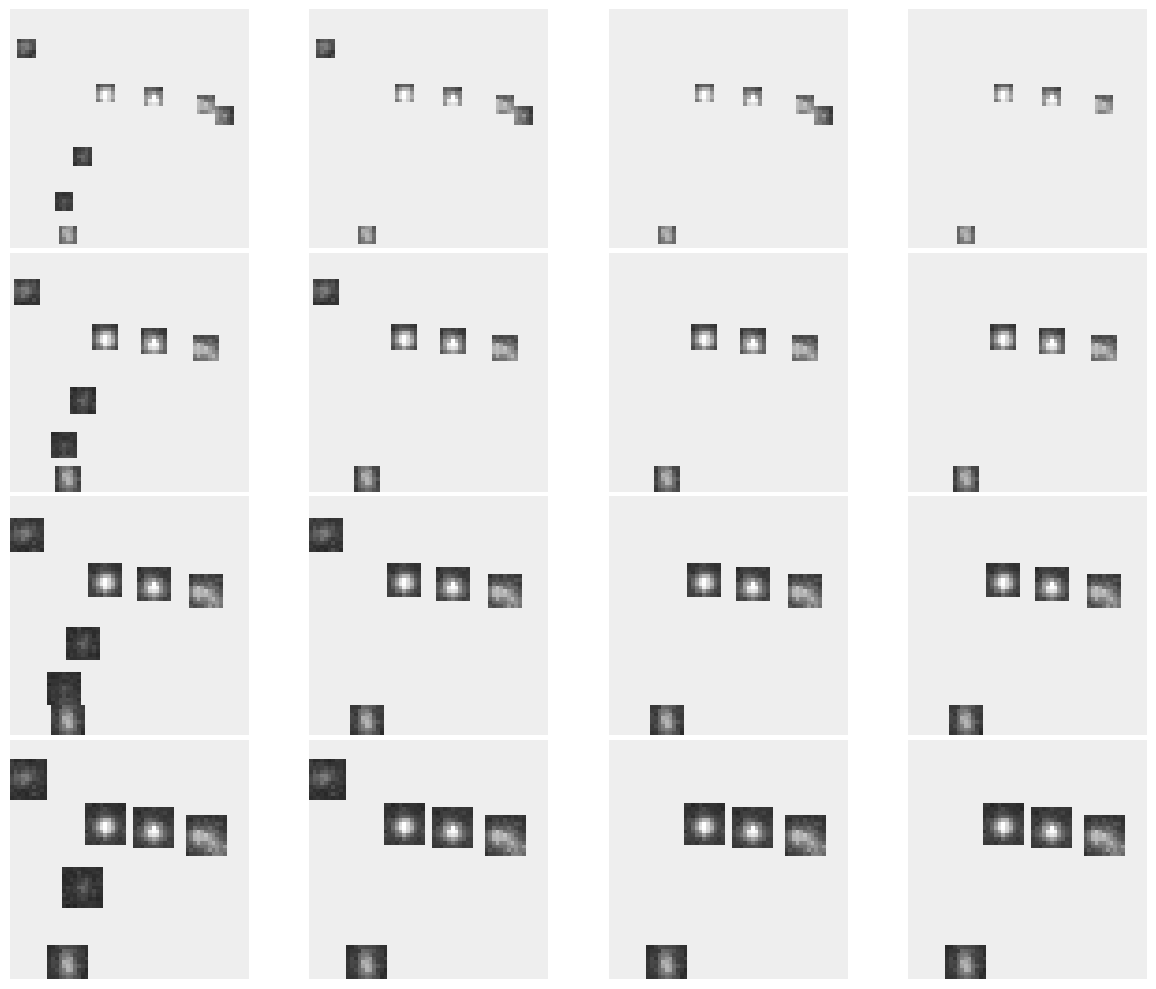

In [10]:

main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism"
# Load and plot
load_and_plot_npz_files(main_folder_path)

### Jaccard index

In [78]:
import glob
import os
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pointcloud_utils as pcu 
# ----------- Path setup -------------
search_root = '/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism'
pattern = "sparz_k*_rt*_lev*/uncompressed/*.csv"
raw_file = '/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism_raw/sequence-as-stack-MT0.N1.HD-AS-Exp.csv'

# ----------- Locate files -------------
loc_files = glob.glob(os.path.join(search_root, pattern), recursive=True)
print(f"Found {len(loc_files)} CSV files.")

# ----------- Extraction helpers -------------

def load_localizations(filepath):
    """Loads localizations from ThunderSTORM CSV or HDF5."""
    if filepath.endswith(".hdf5"):
        with h5py.File(filepath, 'r') as f:
            if 'locs_colnames' in f:
                cols = [c.decode() if isinstance(c, bytes) else c for c in f['locs_colnames'][:]]
            else:
                cols = ['x', 'y']  # fallback
            data = np.array(f['locs'][:])
            return pd.DataFrame(data, columns=cols)
    elif filepath.endswith('.csv'):
        df = pd.read_csv(filepath)
        # Standardize common TS/Picasso conventions
        col_lookup = {c.lower().replace('[', '').replace(']', '').replace(' ', '') : c for c in df.columns}
        for z_key in ('z', 'znm', 'z[nm]'):
            if z_key in col_lookup:
                z_col = col_lookup[z_key]
                break
        else:
            z_col = None
        # Ensure x,y,z columns exist
        if z_col:
            return df.rename(columns={z_col: 'z'})
        else:
            return df
    else:
        raise ValueError("Unrecognized file format: %s" % filepath)

def extract_xyz(df):
    """Extracts (x, y, z) columns as float ndarray"""
    for xname in ['x', 'x [nm]', 'x [pix]']:  # Add more if needed
        if xname in df.columns:
            xcol = xname
            break
    else:
        raise ValueError(f"No x column found in: {df.columns}")
    for yname in ['y', 'y [nm]', 'y [pix]']:
        if yname in df.columns:
            ycol = yname
            break
    else:
        raise ValueError(f"No y column found in: {df.columns}")
    # z column optional
    zcol = None
    for zname in ['z', 'z [nm]', 'z [pix]']:
        if zname in df.columns:
            zcol = zname
            break
    cols = [xcol, ycol] + ([zcol] if zcol else [])
    xyz = df[cols].astype(float).to_numpy()
    if xyz.shape[1] == 2:  # Force 3d shape for 3d matching
        xyz = np.pad(xyz, ((0,0),(0,1)), 'constant')
    return xyz

def parse_k_rt_lev(path):
    """Extracts k, rt, lev integers from path string"""
    match = re.search(r"sparz_k(\d+)_rt(\d+)_lev(\d+)", path)
    if match:
        return tuple(map(int, match.groups()))
    else:
        return (None, None, None)

# ----------- Load gold standard -------------
print("Loading RAW reference...")
raw_df = load_localizations(raw_file)
raw_xyz = extract_xyz(raw_df)
print(f"{len(raw_xyz)} localizations in RAW.")

# ------------ Jaccard index computation ---------------
results_jaccard = []

for comp_file in loc_files:
    print(f"Processing: {comp_file}")
    try:
        comp_df = load_localizations(comp_file)
        print(f"  {len(comp_df)} localizations in compressed file.")
        comp_xyz = extract_xyz(comp_df)
        # You must provide or define this function!
        jaccard = pcu.compute_jaccard_similarity_manual(raw_xyz, comp_xyz, voxel_size=40) # pick a suitable voxel size in nm
        k, rt, lev = parse_k_rt_lev(comp_file)
        results_jaccard.append({
            'k': k, 'rt': rt, 'lev': lev, 
            'file': comp_file, 
            'jaccard': jaccard
        })
    except Exception as e:
        print(f"FAILED: {comp_file}\n  {e}")

result_df = pd.DataFrame(results_jaccard)
result_df = result_df.sort_values(['k', 'rt', 'lev']).reset_index(drop=True)

print(result_df)

Found 64 CSV files.
Loading RAW reference...
13424 localizations in RAW.
Processing: /Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism/sparz_k5_rt65_lev1/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-AS-Exp_compression_level_1.csv
  13464 localizations in compressed file.
Processing: /Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism/sparz_k7_rt65_lev2/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-AS-Exp_compression_level_2.csv
  14298 localizations in compressed file.
Processing: /Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_4_data/astigmatism/sparz_k11_rt65_lev1/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-AS-Exp_compression_level_1.csv
  13446 localizations in compressed file.
Processing: /Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_loc

/var/folders/n4/82zt36bj3190s97jwk9jxc580000gn/T/ipykernel_78265/3475408182.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/laurabreimann/miniforge3/envs/sparz/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/laurabreimann/miniforge3/envs/sparz/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/laurabreimann/miniforge3/envs/sparz/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When gro

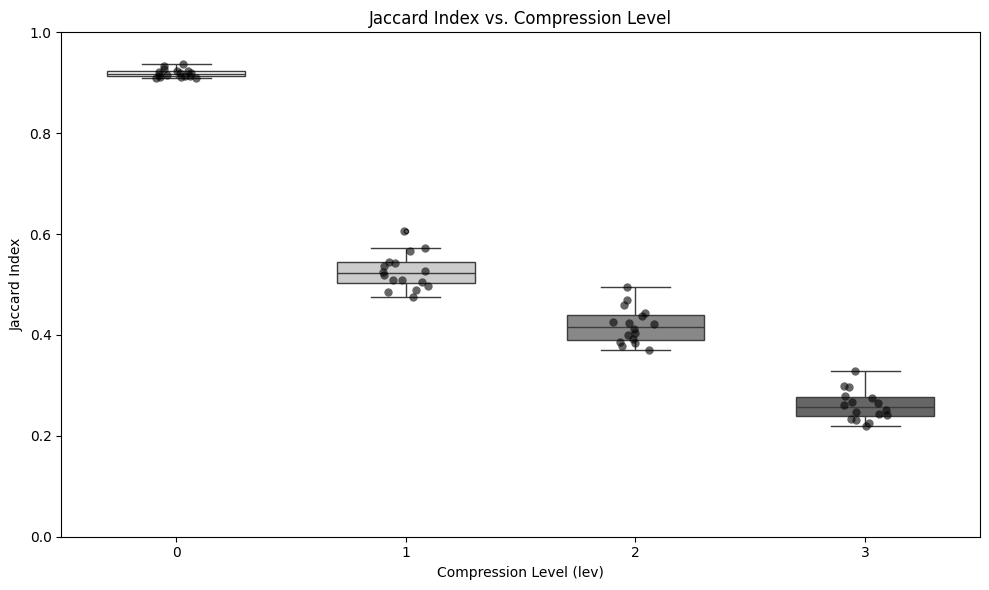

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for each lev (white to dark gray)
lev_palette = {
    "0": "white",
    "1": "#cccccc",
    "2": "#888888",
    "3": "#666666"
}

plt.figure(figsize=(10,6))
sns.boxplot(
    x='lev', y='jaccard',
    data=result_df,
    palette=lev_palette,
    width=0.6,
    fliersize=3,
    dodge=False
)
sns.stripplot(
    x='lev', y='jaccard',
    data=result_df,
    color='black',
    jitter=True,
    size=6,
    alpha=0.6,
    dodge=False
)
plt.xlabel('Compression Level (lev)')
plt.ylabel('Jaccard Index')
plt.title('Jaccard Index vs. Compression Level')
plt.ylim(0, 1)  
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_4_Jaccard_astigmatism_250908.pdf', format='pdf')
plt.show()

# DNA PAINT

In [24]:

main_folder = '/Volumes/T9/DNA-PAINT'
original_file = '/Volumes/T9/DNA-PAINT_raw/raw/RawFramesforTraining_P5-IS_20pM.tif'


In [27]:
# Original file size
original_file_size = 2644997930    # in bytes


# Color map for kernel sizes
k_colors = plt.cm.viridis(np.linspace(0, 1, 4))
lev_shades = np.linspace(0.5, 1, 4)
k_values = [11,15,19,23]

# Marker map for threshold values
threshold_markers = {15: 'o', 25: '^', 35: 's', 45: 'd'}

# Iterate through each subfolder and calculate median SSIM score and file size
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        uncompressed_folder = os.path.join(main_folder, folder)
        # Handling different file endings by searching for the common beginning
        for file_name in os.listdir(uncompressed_folder):
            if file_name.startswith('NP5') and file_name.endswith('.tif'):
                compressed_file = os.path.join(uncompressed_folder, file_name)
                break
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])  
        file_size_percentage = (total_file_size / original_file_size) * 100
        k_value, lev_value = extract_k_lev(folder)
        threshold = int(re.search(r'rt(\d+)', folder).group(1))  # Extract threshold value

        # Choose marker based on threshold value
        marker = threshold_markers[threshold]

        color = k_colors[k_values.index(k_value)]

        # Choose shade based on lev value
        shade = lev_shades[lev_value] if lev_value is not None else 0.5

        if lev_value not in results:
            results[lev_value] = []
        results[lev_value].append({'median_ssim': median_ssim, 'file_size_percentage': file_size_percentage, 'color': color, 'shade': shade, 'marker': marker })

In [28]:
#show results table
df = pd.DataFrame(results)  
save_path = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Results_DNA-PAINT_250908.csv'
df.to_csv(save_path)
print(df)

                                                    0  \
0   {'median_ssim': 0.9930132319065272, 'file_size...   
1   {'median_ssim': 0.9929620081803741, 'file_size...   
2   {'median_ssim': 0.9929322643227388, 'file_size...   
3   {'median_ssim': 0.9929156320759293, 'file_size...   
4   {'median_ssim': 0.993179521868554, 'file_size_...   
5   {'median_ssim': 0.9930673689896411, 'file_size...   
6   {'median_ssim': 0.9929982717227106, 'file_size...   
7   {'median_ssim': 0.9929553406521919, 'file_size...   
8   {'median_ssim': 0.9934162863231752, 'file_size...   
9   {'median_ssim': 0.9932228530274059, 'file_size...   
10  {'median_ssim': 0.9930943672170726, 'file_size...   
11  {'median_ssim': 0.9930137451773292, 'file_size...   
12  {'median_ssim': 0.9936748353566828, 'file_size...   
13  {'median_ssim': 0.993403740186088, 'file_size_...   
14  {'median_ssim': 0.9932041265457635, 'file_size...   
15  {'median_ssim': 0.9930800882942815, 'file_size...   

                              

In [31]:
# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (level, data_list) in enumerate(sorted(results.items())):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for data in data_list:
        ax.scatter(data['file_size_percentage'], data['median_ssim'], color=data['color'],s=250, marker=data['marker'], alpha=0.9)
    ax.set_xlim(0, 20)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

plt.tight_layout()
#plt.show()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_4_SSIM_filesize_DNA-PAINT_250908.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()

## Overview images from grid search

In [64]:
# Define the parameters used in grid search
kernel_sizes = [11,15,19,23]  
rel_thresholds = [0.15, 0.25, 0.35, 0.45]  
compression_levels = [0, 1, 2, 3]  

In [ ]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    coords = data['coords']            # shape: (ndim, Npoints)
    sparse_data = data['data']         # shape: (Npoints,)
    full_array = np.zeros(shape)       # fill_value is 0

    # coords is (ndim, N) so use tuple(coords) for advanced indexing
    full_array[tuple(coords)] = sparse_data
    return full_array

# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds), figsize=(12, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['RawFramesforTraining_P5-IS_20pM.npz'] 
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) #+ index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('#eeeeee')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')
   

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure4_PAINT.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']
Keys in NPZ: ['data', 'coords', 'shape']


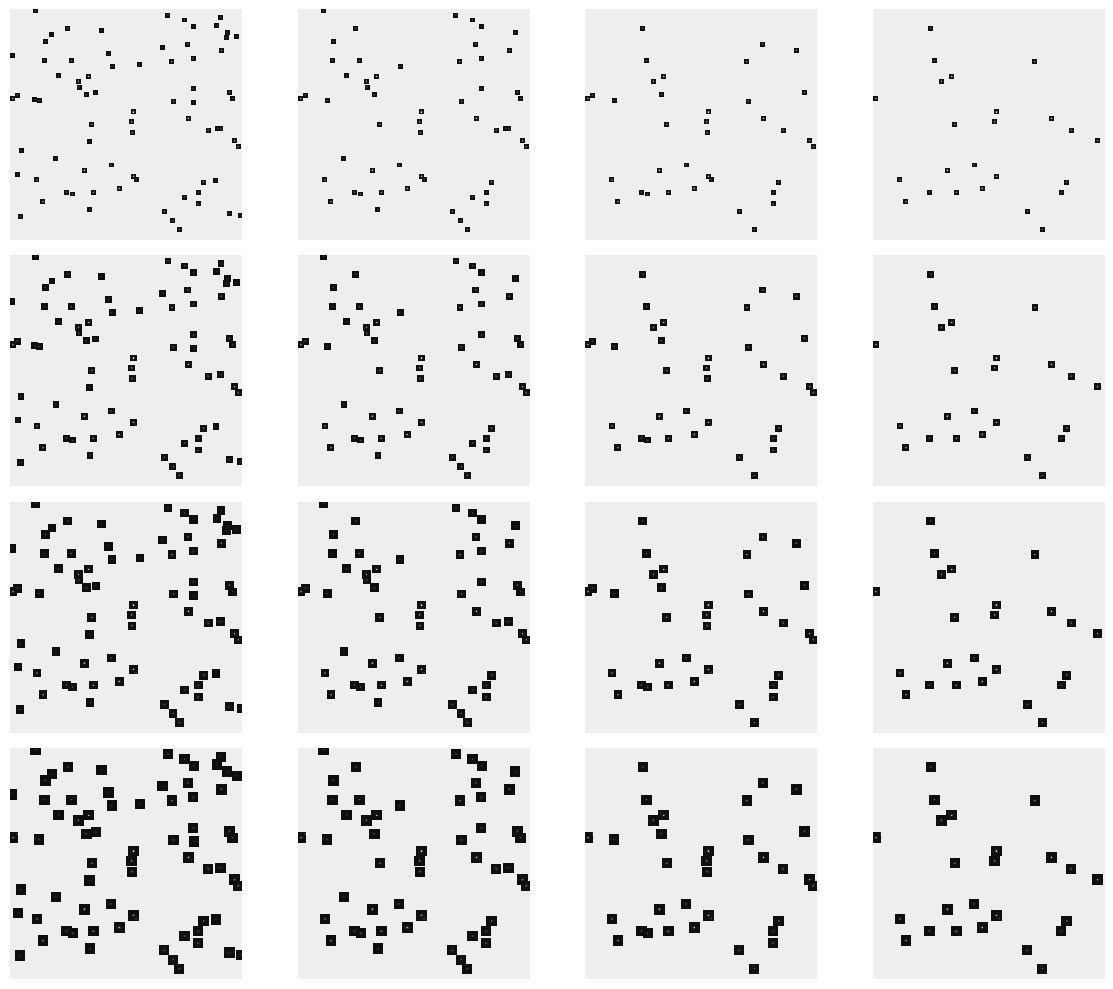

In [70]:

main_folder_path = "/Volumes/T9/DNA-PAINT"
# Load and plot
load_and_plot_npz_files(main_folder_path)

### Mean Jaccard index

==== File Structure ====
locs (Dataset)

==== Dataset Info ====
Dataset name:  /locs
Shape:  (246977,)
Dtype:  [('frame', '<u4'), ('x', '<f4'), ('y', '<f4'), ('photons', '<f4'), ('sx', '<f4'), ('sy', '<f4'), ('bg', '<f4'), ('lpx', '<f4'), ('lpy', '<f4'), ('net_gradient', '<f4'), ('likelihood', '<f4'), ('iterations', '<i4')]
Attributes:  {}

Fields in dataset: frame, x, y, photons, sx, sy, bg, lpx, lpy, net_gradient, likelihood, iterations
Number of localizations:  246977


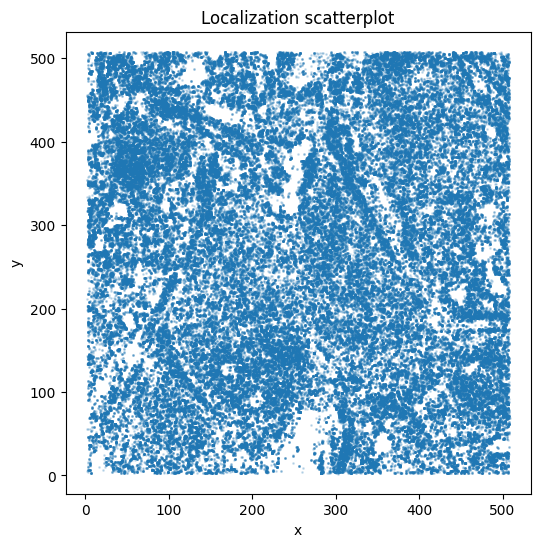

In [35]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Path to your file
filename = "/Volumes/T9/DNA-PAINT_raw/raw/localizations/RawFramesforTraining_P5-IS_20pM_locs.hdf5"

with h5py.File(filename, 'r') as f:
    # Print all groups and datasets recursively
    def print_h5_structure(g, prefix=''):
        for key in g:
            item = g[key]
            print(prefix + key, "(Group)" if isinstance(item, h5py.Group) else "(Dataset)")
            # Recurse into group
            if isinstance(item, h5py.Group):
                print_h5_structure(item, prefix + "  ")

    print("==== File Structure ====")
    print_h5_structure(f)
    print("=======================")

    # Common names for localization tables. Adjust as needed!
    possible_dataset_names = [
        'localizations', 'locs', 'positions', 'coords', 'data/localizations', 'data/locs'
    ]

    # Function to find the first localization dataset
    def find_localization_dataset(h5file, possible_names):
        for dsname in possible_names:
            if dsname in h5file:
                return h5file[dsname]
            # check recursively
            for grp in h5file.values():
                if isinstance(grp, h5py.Group) and dsname in grp:
                    return grp[dsname]
        # If not found, just pick first dataset
        for item in h5file.values():
            if isinstance(item, h5py.Dataset):
                print("WARNING: Using first dataset found:", item.name)
                return item
            elif isinstance(item, h5py.Group):
                dset = find_localization_dataset(item, possible_names)
                if dset:
                    return dset
        return None

    ds = find_localization_dataset(f, possible_dataset_names)
    if ds is None:
        raise RuntimeError("Could not find localization dataset!")

    print("\n==== Dataset Info ====")
    print("Dataset name: ", ds.name)
    print("Shape: ", ds.shape)
    print("Dtype: ", ds.dtype)
    print("Attributes: ", dict(ds.attrs))
    print("======================")

    # Assuming a table, maybe already in structured array format
    locs = ds[:]

    # Print field names if structured dtype
    if locs.dtype.fields is not None:
        print("\nFields in dataset:", ', '.join(locs.dtype.fields.keys()))
        # Assuming columns 'x' and 'y' (change as needed)
        x = locs['x']
        y = locs['y']
    else:
        print("Data is not a structured array, shape:", locs.shape)
        # Try using columns 0 and 1 if 2D
        x = locs[:,0]
        y = locs[:,1]

    print("Number of localizations: ", len(x))

    # --- Simple XY scatterplot ---
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, s=1, alpha=0.2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Localization scatterplot')
    plt.axis('equal')
    plt.show()

In [38]:
import numpy as np
import h5py

with h5py.File('/Volumes/T9/DNA-PAINT_raw/raw/localizations/RawFramesforTraining_P5-IS_20pM_locs.hdf5', 'r') as f:
    locs = f['locs'][:]
lpx = locs['lpx']
lpy = locs['lpy']

lpx_nm = lpx * 130
lpy_nm = lpy * 130

print("lpx avg: {:.2f} nm, median: {:.2f} nm, min: {:.2f}, max: {:.2f}".format(
    lpx_nm.mean(), np.median(lpx_nm), lpx_nm.min(), lpx_nm.max()))
print("lpy avg: {:.2f} nm, median: {:.2f} nm, min: {:.2f}, max: {:.2f}".format(
    lpy_nm.mean(), np.median(lpy_nm), lpy_nm.min(), lpy_nm.max()))

lpx avg: 3.18 nm, median: 2.92 nm, min: 0.00, max: 23.33
lpy avg: 3.06 nm, median: 2.89 nm, min: 0.00, max: 34.52


In [39]:
import glob
import os
import re
import h5py
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import pointcloud_utils as pcu  

# ----------- Path setup -------------
search_root = "/Volumes/T9/DNA-PAINT/"
pattern = "sparz_k*_rt*_lev*/localizations/*_locs.*"
# Path to your gold-standard "raw" file
raw_file = "/Volumes/T9/DNA-PAINT_raw/raw/localizations/RawFramesforTraining_P5-IS_20pM_locs.hdf5"

# ----------- Locate files -------------
loc_files = glob.glob(os.path.join(search_root, pattern), recursive=True)
print(f"Found {len(loc_files)} files.")

# ----------- Extraction helpers -------------

def load_localizations(filepath):
    """Loads localizations from Picasso-style HDF5 or YAML files into DataFrame"""
    if filepath.endswith(".hdf5"):
        with h5py.File(filepath, 'r') as f:
            if 'locs_colnames' in f:
                cols = [c.decode() if isinstance(c, bytes) else c for c in f['locs_colnames'][:]]
            else:
                cols = ['x', 'y']  # fallback
            data = np.array(f['locs'][:])
            return pd.DataFrame(data, columns=cols)

def extract_xyz(df):
    """Extracts (x,y[,z]) cols as numpy array"""
    cols = [c for c in ['x', 'y', 'z'] if c in df.columns]
    return df[cols].to_numpy()

def parse_k_rt_lev(path):
    """Extracts k, rt, lev integers from path string"""
    match = re.search(r"sparz_k(\d+)_rt(\d+)_lev(\d+)", path)
    if match:
        return tuple(map(int, match.groups()))
    else:
        return (None, None, None)

# ----------- Load gold standard -------------
print("Loading RAW reference...")
raw_df = load_localizations(raw_file)
raw_xyz = extract_xyz(raw_df)
print(f"{len(raw_xyz)} localizations in RAW.")




Found 64 files.
Loading RAW reference...
246977 localizations in RAW.


In [42]:
# ------------ Jaccard index computation ---------------
results_jaccard = []

for comp_file in loc_files:
    print(f"Processing: {comp_file}")
    try:
        comp_df = load_localizations(comp_file)
        print(f"  {len(comp_df)} localizations in compressed file.")
        comp_xyz = extract_xyz(comp_df)
        jaccard = pcu.compute_jaccard_similarity_manual(raw_xyz, comp_xyz, voxel_size=5) # need to decide on voxel size
        k, rt, lev = parse_k_rt_lev(comp_file)
        results_jaccard.append({
            'k': k, 'rt': rt, 'lev': lev, 
            'file': comp_file, 
            'jaccard': jaccard
        })
    except Exception as e:
        print(f"FAILED: {comp_file}\n  {e}")

result_df = pd.DataFrame(results_jaccard)
result_df = result_df.sort_values(['k', 'rt', 'lev']).reset_index(drop=True)

display(result_df)


Processing: /Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev0/localizations/NP5_RawFramesforTraining_P5-IS_20pM_compression_level_0_locs.hdf5
  246972 localizations in compressed file.
Processing: /Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev1/localizations/NP5_RawFramesforTraining_P5-IS_20pM_compression_level_1_locs.hdf5
  247078 localizations in compressed file.
Processing: /Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev2/localizations/NP5_RawFramesforTraining_P5-IS_20pM_compression_level_2_locs.hdf5
  271617 localizations in compressed file.
Processing: /Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev3/localizations/NP5_RawFramesforTraining_P5-IS_20pM_compression_level_3_locs.hdf5
  319841 localizations in compressed file.
Processing: /Volumes/T9/DNA-PAINT/sparz_k11_rt25_lev0/localizations/NP5_RawFramesforTraining_P5-IS_20pM_compression_level_0_locs.hdf5
  246883 localizations in compressed file.
Processing: /Volumes/T9/DNA-PAINT/sparz_k11_rt25_lev1/localizations/NP5_RawFramesforTraining_P5-IS_20pM_compression

,k,rt,lev,file,jaccard
0,11,15,0,/Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev0/loca...,1.000000
1,11,15,1,/Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev1/loca...,0.998979
2,11,15,2,/Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev2/loca...,0.994408
3,11,15,3,/Volumes/T9/DNA-PAINT/sparz_k11_rt15_lev3/loca...,0.992995
4,11,25,0,/Volumes/T9/DNA-PAINT/sparz_k11_rt25_lev0/loca...,0.999285
...,...,...,...,...,...
59,23,35,3,/Volumes/T9/DNA-PAINT/sparz_k23_rt35_lev3/loca...,0.940180
60,23,45,0,/Volumes/T9/DNA-PAINT/sparz_k23_rt45_lev0/loca...,0.999183
61,23,45,1,/Volumes/T9/DNA-PAINT/sparz_k23_rt45_lev1/loca...,0.978916
62,23,45,2,/Volumes/T9/DNA-PAINT/sparz_k23_rt45_lev2/loca...,0.959732


/var/folders/n4/82zt36bj3190s97jwk9jxc580000gn/T/ipykernel_78265/1452057625.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/laurabreimann/miniforge3/envs/sparz/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/laurabreimann/miniforge3/envs/sparz/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/laurabreimann/miniforge3/envs/sparz/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When gro

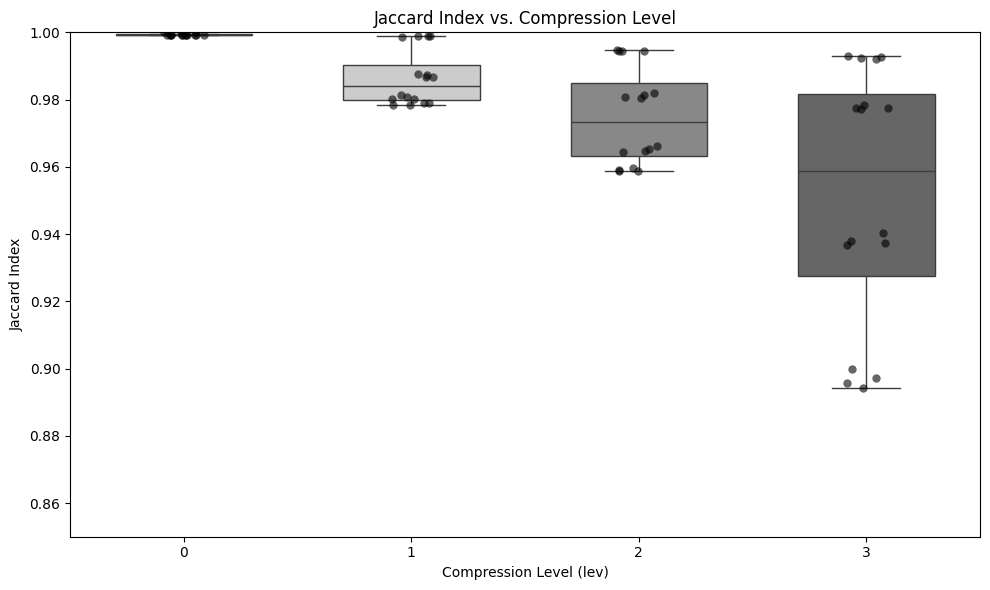

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for each lev (white to dark gray)
lev_palette = {
    "0": "white",
    "1": "#cccccc",
    "2": "#888888",
    "3": "#666666"
}

plt.figure(figsize=(10,6))
sns.boxplot(
    x='lev', y='jaccard',
    data=result_df,
    palette=lev_palette,
    width=0.6,
    fliersize=3,
    dodge=False
)
sns.stripplot(
    x='lev', y='jaccard',
    data=result_df,
    color='black',
    jitter=True,
    size=6,
    alpha=0.6,
    dodge=False
)
plt.xlabel('Compression Level (lev)')
plt.ylabel('Jaccard Index')
plt.title('Jaccard Index vs. Compression Level')
plt.ylim(0.85, 1)  
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_4_Jaccard_DNA-PAINT_250908.pdf', format='pdf')
plt.show()